# Autoencoder Implementation & Regularization Study on MNIST

This notebook trains and compares dense autoencoders, denoising autoencoders, regularized variants, a PCA baseline, and an optional variational autoencoder on MNIST.

## 1. Setup and Imports

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from sklearn.decomposition import PCA

from src.evaluate import compute_mse, run_full_comparison
from src.models import BasicAutoencoder, DenoisingAutoencoder, RegularizedAutoencoder, VAE
from src.train import get_dataloaders, train_model
from src.visualize import plot_latent_tsne, plot_loss_curves, plot_noisy_comparison, plot_reconstructions

sns.set_theme(style='whitegrid')
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPOCHS = 5
print(f'Using device: {device}')

Using device: cpu


## 2. Load MNIST Dataset

Train size: 50000
Validation size: 10000
Test size: 10000


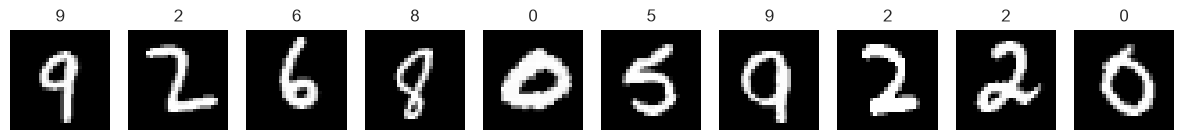

In [2]:
train_loader, val_loader, test_loader = get_dataloaders(batch_size=128)
print(f'Train size: {len(train_loader.dataset)}')
print(f'Validation size: {len(val_loader.dataset)}')
print(f'Test size: {len(test_loader.dataset)}')

sample_images, sample_labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 10, figsize=(12, 2))
for idx, ax in enumerate(axes):
    ax.imshow(sample_images[idx].squeeze(), cmap='gray')
    ax.set_title(str(sample_labels[idx].item()))
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Basic Autoencoder (latent_dim=32)

The basic autoencoder flattens each 28x28 image into 784 features, compresses it through 512 and 256 hidden units into a 32-dimensional latent vector, then reconstructs the original image with a symmetric decoder.

In [3]:
basic_ae = BasicAutoencoder(latent_dim=32)
basic_history = train_model(basic_ae, train_loader, val_loader, epochs=EPOCHS, patience=5, device=device)
plot_loss_curves(basic_history, title='basic_autoencoder')
plot_reconstructions(basic_ae, test_loader, device, n=10, title='basic_autoencoder')
basic_mse = compute_mse(basic_ae, test_loader, device)
print(f'Basic AE test MSE: {basic_mse:.6f}')

Training:   0%|          | 0/5 [00:00<?, ?epoch/s]

Basic AE test MSE: 0.008374


## 4. Denoising Autoencoder

Denoising autoencoders corrupt their inputs during training and learn to reconstruct the clean target, encouraging latent features that are robust to Gaussian and salt-and-pepper noise.

In [4]:
denoising_gaussian = DenoisingAutoencoder(latent_dim=32, noise_type='gaussian')
gaussian_history = train_model(denoising_gaussian, train_loader, val_loader, epochs=EPOCHS, patience=5, device=device)
plot_loss_curves(gaussian_history, title='denoising_gaussian')
plot_noisy_comparison(denoising_gaussian, test_loader, device)

denoising_sp = DenoisingAutoencoder(latent_dim=32, noise_type='salt_pepper')
sp_history = train_model(denoising_sp, train_loader, val_loader, epochs=EPOCHS, patience=5, device=device)
plot_loss_curves(sp_history, title='denoising_salt_pepper')
plot_reconstructions(denoising_sp, test_loader, device, n=10, title='denoising_salt_pepper')

Training:   0%|          | 0/5 [00:00<?, ?epoch/s]

Training:   0%|          | 0/5 [00:00<?, ?epoch/s]

PosixPath('results/plots/denoising_salt_pepper_reconstructions.png')

## 5. Regularization Comparison

This section compares no regularization, L2 weight decay, dropout, and early stopping. L2 discourages large weights, dropout injects stochastic feature removal, and early stopping stops training once validation loss stops improving.

Training:   0%|          | 0/5 [00:00<?, ?epoch/s]

Training:   0%|          | 0/5 [00:00<?, ?epoch/s]

Training:   0%|          | 0/5 [00:00<?, ?epoch/s]

Training:   0%|          | 0/10 [00:00<?, ?epoch/s]

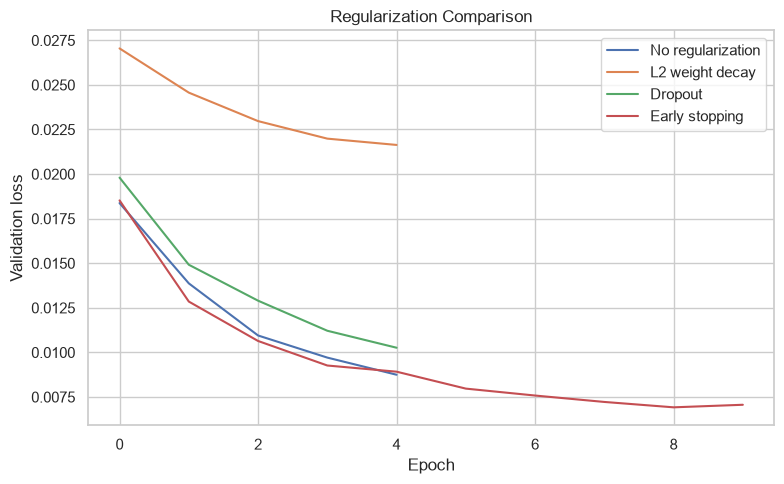

In [5]:
regularization_runs = {
    'No regularization': (BasicAutoencoder(32), 0.0, EPOCHS, 50),
    'L2 weight decay': (BasicAutoencoder(32), 1e-4, EPOCHS, 50),
    'Dropout': (RegularizedAutoencoder(32, dropout_p=0.2), 0.0, EPOCHS, 50),
    'Early stopping': (BasicAutoencoder(32), 0.0, max(EPOCHS, 10), 5),
}

regularization_histories = {}
for label, (model, weight_decay, epochs, patience) in regularization_runs.items():
    regularization_histories[label] = train_model(
        model,
        train_loader,
        val_loader,
        epochs=epochs,
        weight_decay=weight_decay,
        patience=patience,
        device=device,
    )

fig, ax = plt.subplots(figsize=(8, 5))
for label, history in regularization_histories.items():
    ax.plot(history['val_losses'], label=label)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation loss')
ax.set_title('Regularization Comparison')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Latent Space Size Analysis

Smaller latent spaces force stronger compression and can remove detail; larger latent spaces usually reconstruct better but may learn less compact representations.

Training:   0%|          | 0/5 [00:00<?, ?epoch/s]

Training:   0%|          | 0/5 [00:00<?, ?epoch/s]

Training:   0%|          | 0/5 [00:00<?, ?epoch/s]

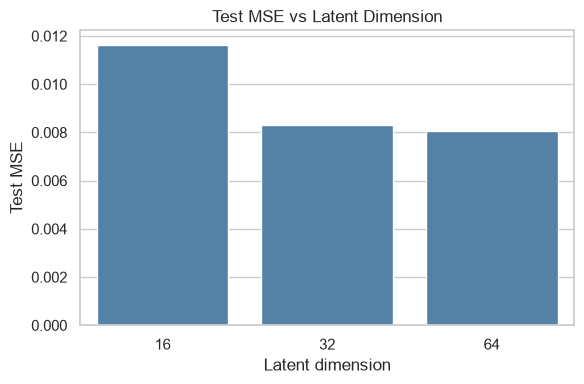

,latent_dim,test_mse
0,16,0.011646
1,32,0.008295
2,64,0.008060


In [6]:
latent_results = []
latent_models = {}
for latent_dim in [16, 32, 64]:
    model = BasicAutoencoder(latent_dim=latent_dim)
    train_model(model, train_loader, val_loader, epochs=EPOCHS, patience=5, device=device)
    mse = compute_mse(model, test_loader, device)
    latent_results.append({'latent_dim': latent_dim, 'test_mse': mse})
    latent_models[latent_dim] = model
    plot_reconstructions(model, test_loader, device, n=10, title=f'latent_dim_{latent_dim}')

latent_df = pd.DataFrame(latent_results)
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=latent_df, x='latent_dim', y='test_mse', ax=ax, color='steelblue')
ax.set_title('Test MSE vs Latent Dimension')
ax.set_xlabel('Latent dimension')
ax.set_ylabel('Test MSE')
plt.tight_layout()
plt.show()
latent_df

## 7. PCA Baseline

PCA gives a strong linear compression baseline. Comparing against PCA helps show whether the neural autoencoder learns a useful nonlinear representation.

PCA baseline test MSE: 0.016833


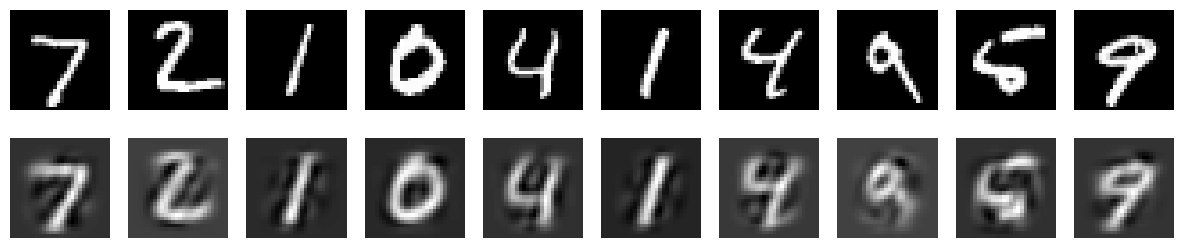

In [7]:
def loader_to_numpy(loader):
    xs, ys = [], []
    for images, labels in loader:
        xs.append(images.view(images.size(0), -1).numpy())
        ys.append(labels.numpy())
    return np.concatenate(xs), np.concatenate(ys)

train_x, _ = loader_to_numpy(train_loader)
test_x, test_y = loader_to_numpy(test_loader)
pca = PCA(n_components=32, random_state=42)
pca.fit(train_x)
pca_recon = pca.inverse_transform(pca.transform(test_x))
pca_mse = np.mean((test_x - pca_recon) ** 2)
print(f'PCA baseline test MSE: {pca_mse:.6f}')

fig, axes = plt.subplots(2, 10, figsize=(12, 3))
for idx in range(10):
    axes[0, idx].imshow(test_x[idx].reshape(28, 28), cmap='gray')
    axes[0, idx].axis('off')
    axes[1, idx].imshow(pca_recon[idx].reshape(28, 28), cmap='gray')
    axes[1, idx].axis('off')
axes[0, 0].set_ylabel('Original')
axes[1, 0].set_ylabel('PCA')
plt.tight_layout()
plt.show()

## 8. Final MSE Comparison Table

The full comparison is generated by `src/evaluate.py` and saved to `results/metrics_table.md`.

In [8]:
metrics_path = PROJECT_ROOT / 'results' / 'metrics_table.md'

def read_markdown_table(path):
    lines = [line.strip() for line in path.read_text().splitlines() if line.strip().startswith('|')]
    rows = []
    for line in lines:
        cells = [cell.strip() for cell in line.strip('|').split('|')]
        if all(set(cell) <= {'-', ':'} for cell in cells):
            continue
        rows.append(cells)
    if len(rows) <= 1:
        return pd.DataFrame(columns=['Model', 'Latent_Dim', 'Regularization', 'Test_MSE'])
    return pd.DataFrame(rows[1:], columns=rows[0])

metrics_df = read_markdown_table(metrics_path)
if metrics_df.empty:
    print('metrics_table.md has no rows yet. Running the full comparison now.')
    metrics_df = run_full_comparison(train_loader, val_loader, test_loader, device)
else:
    metrics_df['Test_MSE'] = pd.to_numeric(metrics_df['Test_MSE'], errors='coerce')

display(metrics_df.style.highlight_min(subset=['Test_MSE'], color='lightgreen'))

metrics_table.md has no rows yet. Running the full comparison now.


Latent dimensions:   0%|          | 0/3 [00:00<?, ?it/s]

Training:   0%|          | 0/50 [00:00<?, ?epoch/s]

Training:   0%|          | 0/50 [00:00<?, ?epoch/s]

Training:   0%|          | 0/50 [00:00<?, ?epoch/s]

...

Training:   0%|          | 0/50 [00:00<?, ?epoch/s]

Training:   0%|          | 0/50 [00:00<?, ?epoch/s]

Training:   0%|          | 0/50 [00:00<?, ?epoch/s]

Training:   0%|          | 0/50 [00:00<?, ?epoch/s]

,Model,Latent_Dim,Regularization,Test_MSE
0,BasicAutoencoder,16,None,0.007962
1,BasicAutoencoder,16,L2 weight_decay=1e-4,0.018866
2,RegularizedAutoencoder,16,Dropout p=0.2,0.008916
3,DenoisingAutoencoder,16,Gaussian noise,0.009917
4,DenoisingAutoencoder,16,Gaussian noise + L2 weight_decay=1e-4,0.020824
5,DenoisingAutoencoder,16,Salt-pepper noise,0.013466
6,DenoisingAutoencoder,16,Salt-pepper noise + L2 weight_decay=1e-4,0.025700
7,BasicAutoencoder,32,None,0.005049
8,BasicAutoencoder,32,L2 weight_decay=1e-4,0.019756
9,RegularizedAutoencoder,32,Dropout p=0.2,0.006107


## 9. Bonus — VAE (Optional)

Training:   0%|          | 0/5 [00:00<?, ?epoch/s]

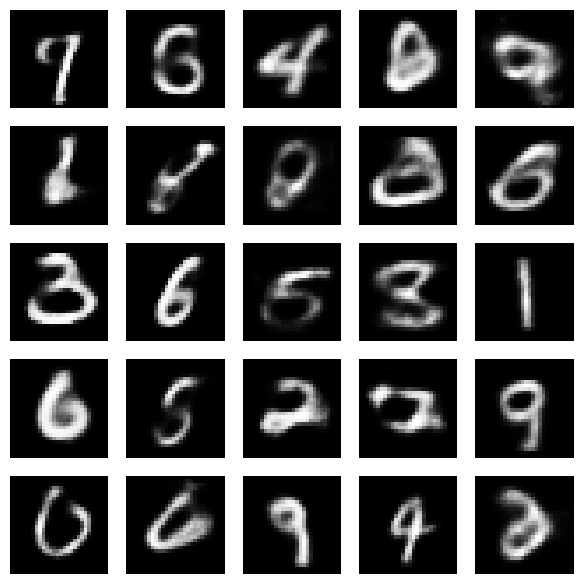

In [9]:
vae = VAE(latent_dim=32)
vae_history = train_model(vae, train_loader, val_loader, epochs=EPOCHS, patience=5, is_vae=True, device=device)
plot_loss_curves(vae_history, title='vae')
plot_reconstructions(vae, test_loader, device, n=10, title='vae')

vae.eval()
with torch.no_grad():
    samples = vae.sample(25, device).cpu().view(-1, 28, 28)
fig, axes = plt.subplots(5, 5, figsize=(6, 6))
for ax, image in zip(axes.ravel(), samples):
    ax.imshow(image, cmap='gray')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 10. Latent Space Visualization

In [10]:
best_model = latent_models[min(latent_results, key=lambda row: row['test_mse'])['latent_dim']] if 'latent_models' in globals() else basic_ae
plot_latent_tsne(best_model, test_loader, device)

PosixPath('results/plots/tsne_latent.png')